# Denoise with NGMeet

In [69]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
from bm3d import bm3d, BM3DStages
from bm4d import bm4d, BM4DStages
import pickle
import copy
import time
import humanfriendly
from skimage.restoration import estimate_sigma
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import random
import humanfriendly

device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load aligned tile (to be denoised)

In [70]:
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)

tile.apply("crop", parameters = {"crop_idx": (slice(50,tile.EDX_dim[0]-50),slice(50,tile.EDX_dim[1]-50),slice(None,None,None))})
tile.apply("binning", parameters={"dim": (974,974,250)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})

#h, w, b = tile.EDX_dim
tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None


### (optional) Load non-aligned tile

In [ ]:
# load data
file_path = "../data/EMD/EDXdataset.emd"
EDX, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100,sum_frames=True)
tile = EM_EDX(haadf, EDX, xray_energies)
tile.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
#tile.apply("binning", parameters={"dim": (1024, 1024, 500)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})


### Load refrence tile

In [72]:
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_ref = pickle.load(file)

tile_ref.apply("crop", parameters = {"crop_idx": (slice(50,tile_ref.EDX_dim[0]-50),slice(50,tile_ref.EDX_dim[1]-50),slice(None,None,None))})
tile_ref.apply("binning", parameters={"dim": (int(tile_ref.EDX_dim[0]/2),int(tile_ref.EDX_dim[1]/2),250)})
tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

#h, w, b = tile.EDX_dim
tile_ref.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_path=tmp/unaligned_hsi_100frames, al...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None


### Optional: additional cropping

In [7]:
tile.apply("crop", parameters = {"crop_idx": (slice(600,900),slice(600,900),slice(None,None,None))})
tile_ref.apply("crop", parameters = {"crop_idx": (slice(600,900),slice(600,900),slice(None,None,None))})

<EM_EDX | 7 steps logged>

### NGMeet in matlab

In [73]:
# Start matlab engine and set path
eng = matlab.engine.start_matlab()
matlab_path = eng.genpath('../matlab/')   # add path recursively
eng.addpath(matlab_path, nargout=0)

### (Optional) Get a 'Hyperspectral tile' from Matlab's libraries for reference

In [ ]:
datacube = eng.imhypercube("paviaU.hdr")
datacube = eng.gather(datacube)

# optional: denoise
datacube = eng.rescale(datacube)
datacube = eng.imnoise(datacube,"Gaussian") #,0,0.005)

datacube = np.asarray(datacube)
fake_haadf = np.sum(datacube,axis=2)
fake_xray_energies = np.ones((datacube.shape[2],1))
tile_pavia = EM_EDX(fake_haadf, datacube, fake_xray_energies)

In [ ]:
# Match their dimensions
tile.apply("crop", parameters = {"crop_idx": (slice(0,tile_pavia.EDX_dim[0]),slice(0,tile_pavia.EDX_dim[1]),slice(None,None,None))})

### Display

In [ ]:
# compare
bands_1 = [4,25,28]
bands_2 = [80,34,9]
f, ax = plt.subplots(1,2,figsize=(10,10))
ax[0].imshow(tile.FalseColor(bands_1))
ax[1].imshow(tile_pavia.FalseColor(bands_2))


### NGMeet parameters

In [74]:
# set dataset to denoise
hsi_noisy = np.ascontiguousarray(tile.EDX)
hsi_noisy, min, max = MinMax(hsi_noisy, return_extra=True)
h,w,b = hsi_noisy.shape


# Optional variance stablilzation
G = np.mean(hsi_noisy,axis=2).reshape(h*w,1)
G = np.ones_like(G)   # optional
H = np.mean(np.mean(hsi_noisy,axis=0),axis=0).reshape(b,-1)
W = G@np.transpose(H)
W = np.sqrt(W)    
hsi_noisy = np.divide(hsi_noisy,W.reshape((h,w,b)))


# Estimate noise
noise_est, noise_corr = est_noise(hsi_noisy.reshape(tile.EDX_2D.shape), 'additive_noise')

### HySime to estimate k

In [75]:
k, _ = hysime(hsi_noisy.reshape(tile.EDX_2D.shape), noise_est, noise_corr)
print(k)
sigma  = np.sqrt(np.var(noise_est))

3


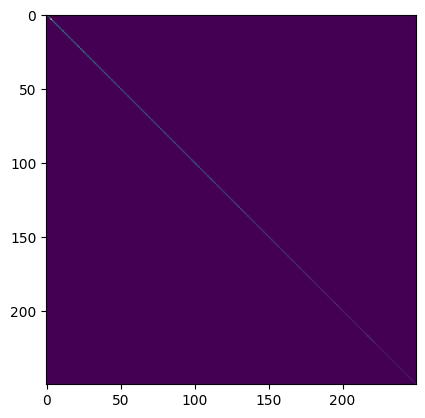

In [76]:
plt.imshow(noise_corr)

In [77]:
print(HfcVd(hsi_noisy.reshape(tile.EDX_2D.shape)))

[250, 250, 250]


### Default value for sigma in the 
- 0.1 times the standard deviation of a channel in the middle.

In [78]:
middel_channel = int(np.ceil(tile.EDX_dim[2]/2))
print("Middle channel: ", middel_channel)
print("Before VTS: ", 0.1*np.std(tile.EDX[:,:,middel_channel]))
print("After VST: ", 0.1*np.std(hsi_noisy[:,:,middel_channel]))
print("Estimate (psp): ", sigma)

Middle channel:  125
Before VTS:  0.0002237163
After VST:  0.0012272013
Estimate (psp):  0.012704454541190081


### Denoising

In [81]:
start = time.perf_counter()

# set dataset to denoise
# hsi_noisy = np.ascontiguousarray(tile.EDX)
# hsi_noisy, min, max = MinMax(hsi_noisy, return_extra=True)


hsi_clean =  eng.denoiseNGMeet(
    hsi_noisy,     
    'Sigma', sigma,
    'SpectralSubspace', k+30,
    'NumIterations', 2,
    nargout=1
)
hsi_clean =  np.asarray(hsi_clean)


# optional undo variance scaling (and minmaxing)
hsi_clean = np.multiply(hsi_clean, W.reshape((h,w,b)))
hsi_clean = MinMaxInverse(hsi_clean, min, max)


# Re-order
#reshuffled_idx = np.argsort(shuffled_idx)
#hsi_clean = hsi_clean[:,:, reshuffled_idx]


# Assign to new tile object
tile_NGMeet = tile.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(None))},copy_instance=True)
tile_NGMeet.EDX = hsi_clean


# time
elapsed = time.perf_counter() - start
print("Elapsed time for denoising:", humanfriendly.format_timespan(elapsed))

Elapsed time for denoising: 8 minutes and 7.7 seconds


### Optional: bin, if it was 500 bands

In [ ]:
tile_NGMeet.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile.apply("binning", parameters={"dim": (1024, 1024, 250)})


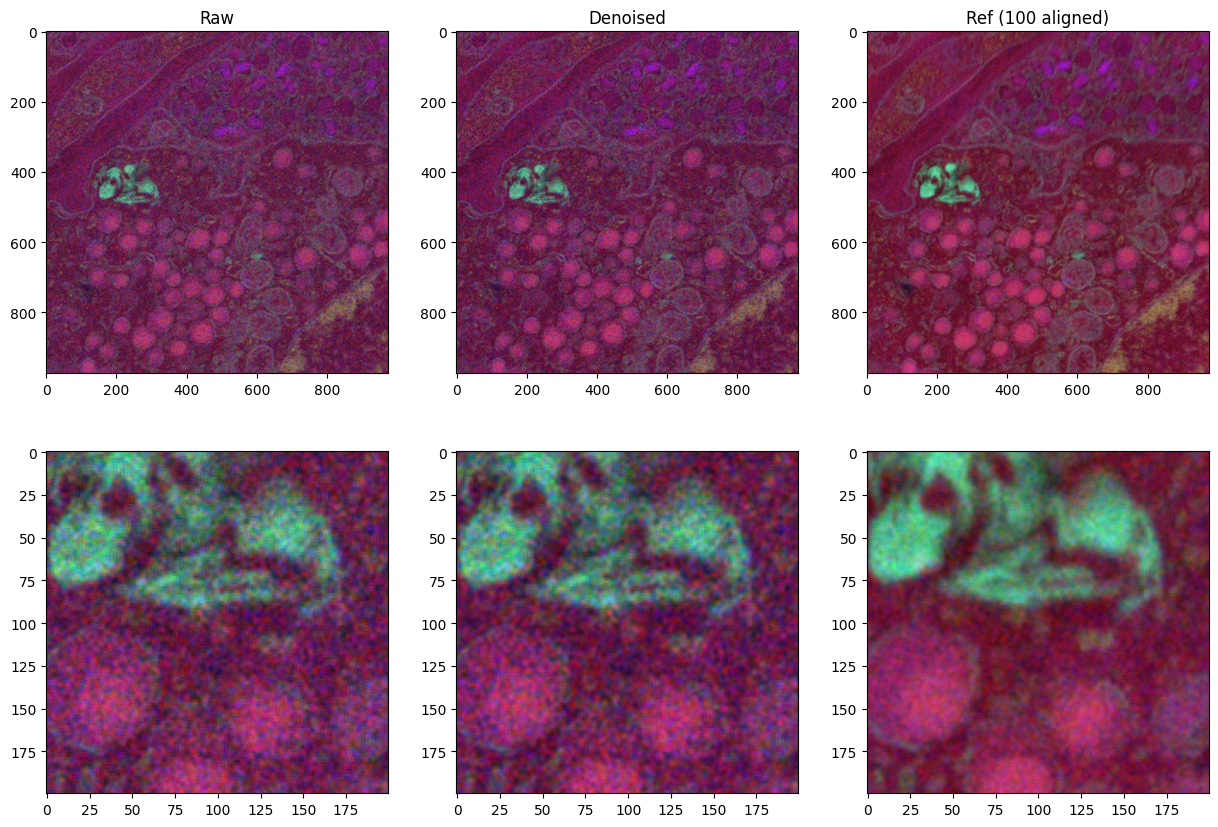

In [82]:
# compare
corr = 0


#bands = [25-corr,25-corr,25-corr]
#bands = [28-corr,28-corr,28-corr]
bands = [4-corr,25-corr,28-corr]
#bands = [4-corr,4-corr,4-corr]



zoom = (slice(400,600),slice(150,350),slice(None))
#zoom = (slice(600,900),slice(600,900),slice(None))3zoom = (slice(None,None),slice(None,None),slice(None))
#zoom = (slice(1250,1750),slice(1250,1750),slice(None))

f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(tile.FalseColor(bands))
ax[0][0].set_title('Raw')
ax[0][1].imshow(tile_NGMeet.FalseColor(bands))
ax[0][1].set_title('Denoised')
ax[0][2].imshow(tile_ref.FalseColor(bands))
ax[0][2].set_title('Ref (100 aligned)')

ax[1][0].imshow(tile.FalseColor(bands)[zoom])
ax[1][1].imshow(tile_NGMeet.FalseColor(bands)[zoom])
ax[1][2].imshow(tile_ref.FalseColor(bands)[zoom])

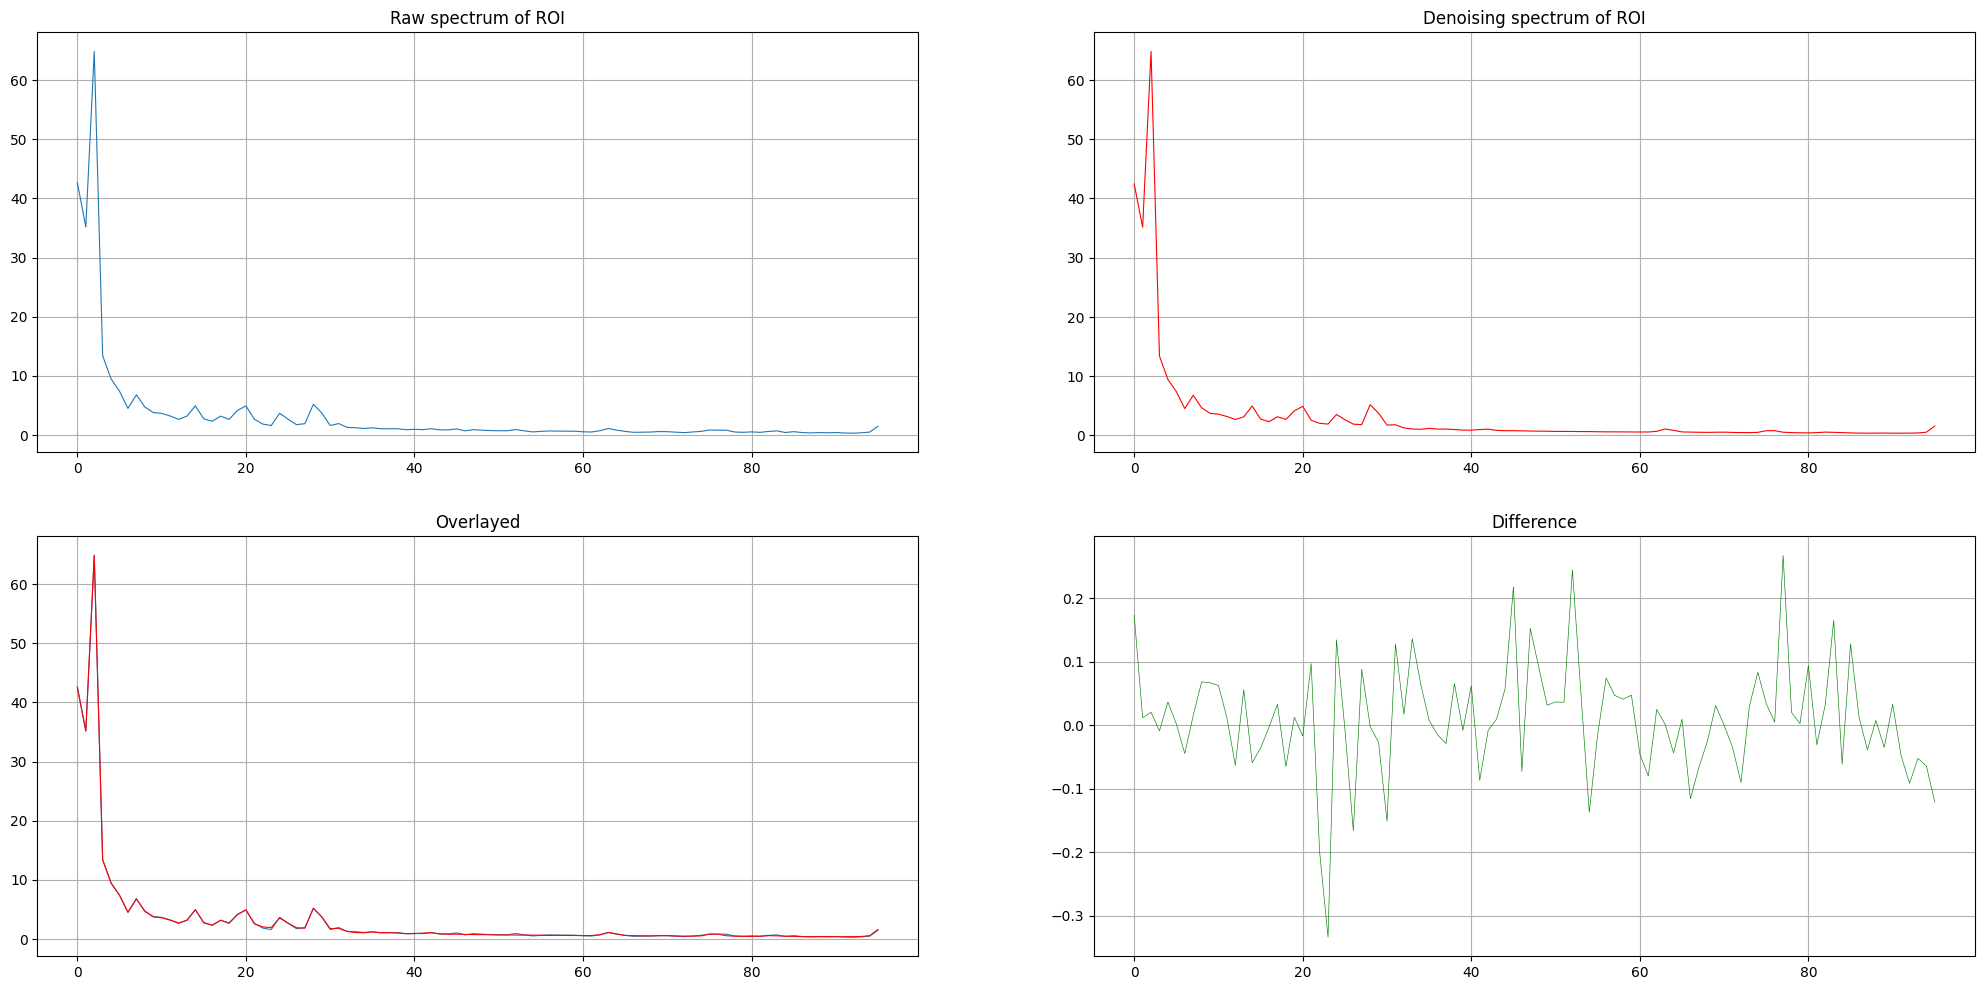

In [83]:
cutoff1 = 4
cutoff2 = 100
spec_data = tile.EDX[210:220, 210:220, cutoff1:cutoff2]
spec_clean = tile_NGMeet.EDX[210:220, 210:220, cutoff1:cutoff2]
lw = 0.8


f, ax = plt.subplots(2,2, figsize = (25,12))
ax[0][0].plot(np.sum(spec_data,axis=(0,1)),lw=lw)
ax[0][0].set_title('Raw spectrum of ROI')
ax[0][1].plot(np.sum(spec_clean,axis=(0,1)),'r',lw=lw)
ax[0][1].set_title('Denoising spectrum of ROI')

ax[1][0].plot(np.sum(spec_data,axis=(0,1)),lw=lw)
ax[1][0].plot(np.sum(spec_clean,axis=(0,1)),'r',lw=lw)
ax[1][0].set_title('Overlayed')


ax[1][1].plot((np.sum(spec_data,axis=(0,1)) - np.sum(spec_clean,axis=(0,1))),'g',lw=0.45)
ax[1][1].set_title('Difference')

for i in range(2):
    for j in range(2):
        ax[i][j].grid('ON')